# English Premier League (EPL) Pythagorean Predictor

## Step 1

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the packages

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data.
# EPL results for the 2017/18 season

EPL18 = pd.read_excel('/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 1 - Foundations of Sports Analytics: Data, Representation, and Models in Sports/Week 1 Content/Week 1 Assignment/EPL2017-18.xlsx')
print(EPL18.columns.tolist())

['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']


## Step 2

In [ ]:
# We first identify whether the result was a win for the home team (H), the away team (A) or a draw (D). We also create the counting variable.

EPL18['hwinvalue']=np.where(EPL18['FTR']=='H',1,np.where(EPL18['FTR']=='D',.5,0))
EPL18['awinvalue']=np.where(EPL18['FTR']=='A',1,np.where(EPL18['FTR']=='D',.5,0))
EPL18['count']=1
EPL18

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
0,20170811,Arsenal,Leicester,4,3,H,1.0,0.0,1
1,20170812,Brighton,Man City,0,2,A,0.0,1.0,1
2,20170812,Chelsea,Burnley,2,3,A,0.0,1.0,1
3,20170812,Crystal Palace,Huddersfield,0,3,A,0.0,1.0,1
4,20170812,Everton,Stoke,1,0,H,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...
375,20180513,Newcastle,Chelsea,3,0,H,1.0,0.0,1
376,20180513,Southampton,Man City,0,1,A,0.0,1.0,1
377,20180513,Swansea,Stoke,1,2,A,0.0,1.0,1
378,20180513,Tottenham,Leicester,5,4,H,1.0,0.0,1


## Step 3

In [ ]:
# Create partitions for games played in 2017 and games played in 2018
EPL17 = EPL18[EPL18.Date < 20180000]
EPL18 = EPL18[EPL18.Date > 20180000]
EPL17

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
0,20170811,Arsenal,Leicester,4,3,H,1.0,0.0,1
1,20170812,Brighton,Man City,0,2,A,0.0,1.0,1
2,20170812,Chelsea,Burnley,2,3,A,0.0,1.0,1
3,20170812,Crystal Palace,Huddersfield,0,3,A,0.0,1.0,1
4,20170812,Everton,Stoke,1,0,H,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...
204,20171230,Man United,Southampton,0,0,D,0.5,0.5,1
205,20171230,Newcastle,Brighton,0,0,D,0.5,0.5,1
206,20171230,Watford,Swansea,1,2,A,0.0,1.0,1
207,20171231,Crystal Palace,Man City,0,0,D,0.5,0.5,1


In [ ]:
EPL18

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,hwinvalue,awinvalue,count
209,20180101,Brighton,Bournemouth,2,2,D,0.5,0.5,1
210,20180101,Burnley,Liverpool,1,2,A,0.0,1.0,1
211,20180101,Everton,Man United,0,2,A,0.0,1.0,1
212,20180101,Leicester,Huddersfield,3,0,H,1.0,0.0,1
213,20180101,Stoke,Newcastle,0,1,A,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...
375,20180513,Newcastle,Chelsea,3,0,H,1.0,0.0,1
376,20180513,Southampton,Man City,0,1,A,0.0,1.0,1
377,20180513,Swansea,Stoke,1,2,A,0.0,1.0,1
378,20180513,Tottenham,Leicester,5,4,H,1.0,0.0,1


## Step 4 (2017)

In [ ]:
# Create a df for 2017 home team performance
EPLhome17 = EPL17.groupby(['HomeTeam'])[['count','hwinvalue', 'FTHG','FTAG']].sum().reset_index()
EPLhome17

,HomeTeam,count,hwinvalue,FTHG,FTAG
0,Arsenal,10,8.5,25,10
1,Bournemouth,11,4.5,14,17
2,Brighton,10,5.5,10,12
3,Burnley,10,6.0,7,6
4,Chelsea,11,8.5,21,7
5,Crystal Palace,11,5.0,14,18
6,Everton,10,6.5,17,13
7,Huddersfield,11,6.0,10,12
8,Leicester,10,5.0,13,14
9,Liverpool,11,8.5,21,4


## Step 5 (2017)

In [ ]:
# Create a df for 2017 away team performance
EPLaway17 = EPL17.groupby(['AwayTeam'])[['count','awinvalue', 'FTHG','FTAG']].sum().reset_index()
EPLaway17

,AwayTeam,count,awinvalue,FTHG,FTAG
0,Arsenal,11,5.0,16,13
1,Bournemouth,10,3.0,15,6
2,Brighton,11,3.0,13,5
3,Burnley,11,6.5,11,11
4,Chelsea,10,7.0,7,18
5,Crystal Palace,10,2.5,14,4
6,Everton,11,3.5,19,8
7,Huddersfield,10,3.0,20,8
8,Leicester,11,5.0,18,18
9,Liverpool,10,6.5,20,27


## Step 6 (2017)



In [ ]:
# Rename the variables in both dataframes to specify home or away
EPLhome17 = EPLhome17.rename(columns={'HomeTeam':'team','count':'Ph','FTHG':'FTHGh','FTAG':'FTAGh'})
EPLaway17 = EPLaway17.rename(columns={'AwayTeam':'team','count':'Pa','FTHG':'FTHGa','FTAG':'FTAGa'})

## Step 7 (2017)

In [ ]:
# Merge the home and away dataframes
EPL17 = pd.merge(EPLhome17, EPLaway17, on = ['team'])
EPL17

,team,Ph,hwinvalue,FTHGh,FTAGh,Pa,awinvalue,FTHGa,FTAGa
0,Arsenal,10,8.5,25,10,11,5.0,16,13
1,Bournemouth,11,4.5,14,17,10,3.0,15,6
2,Brighton,10,5.5,10,12,11,3.0,13,5
3,Burnley,10,6.0,7,6,11,6.5,11,11
4,Chelsea,11,8.5,21,7,10,7.0,7,18
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4
6,Everton,10,6.5,17,13,11,3.5,19,8
7,Huddersfield,11,6.0,10,12,10,3.0,20,8
8,Leicester,10,5.0,13,14,11,5.0,18,18
9,Liverpool,11,8.5,21,4,10,6.5,20,27


## Step 8 (2017)

In [ ]:
# Sum the results for home and away to get overall performance and calculate win percentage and pythagorean expectation
EPL17['W17'] = EPL17['hwinvalue']+EPL17['awinvalue']
EPL17['G17'] = EPL17['Ph']+EPL17['Pa']
EPL17['GF17'] = EPL17['FTHGh']+EPL17['FTAGa']
EPL17['GA17'] = EPL17['FTAGh']+EPL17['FTHGa']
EPL17['wpc17'] = EPL17['W17']/EPL17['G17']
EPL17['pyth17'] = EPL17['GF17']**2/(EPL17['GF17']**2 + EPL17['GA17']**2)
EPL17

,team,Ph,hwinvalue,FTHGh,FTAGh,Pa,awinvalue,FTHGa,FTAGa,W17,G17,GF17,GA17,wpc17,pyth17
0,Arsenal,10,8.5,25,10,11,5.0,16,13,13.5,21,38,26,0.642857,0.681132
1,Bournemouth,11,4.5,14,17,10,3.0,15,6,7.5,21,20,32,0.357143,0.280899
2,Brighton,10,5.5,10,12,11,3.0,13,5,8.5,21,15,25,0.404762,0.264706
3,Burnley,10,6.0,7,6,11,6.5,11,11,12.5,21,18,17,0.595238,0.528548
4,Chelsea,11,8.5,21,7,10,7.0,7,18,15.5,21,39,14,0.738095,0.885847
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4,7.5,21,18,32,0.357143,0.240356
6,Everton,10,6.5,17,13,11,3.5,19,8,10.0,21,25,32,0.476190,0.379018
7,Huddersfield,11,6.0,10,12,10,3.0,20,8,9.0,21,18,32,0.428571,0.240356
8,Leicester,10,5.0,13,14,11,5.0,18,18,10.0,21,31,32,0.476190,0.484131
9,Liverpool,11,8.5,21,4,10,6.5,20,27,15.0,21,48,24,0.714286,0.800000


## Optional steps, not required for Assessment
### (Uncomment to run)

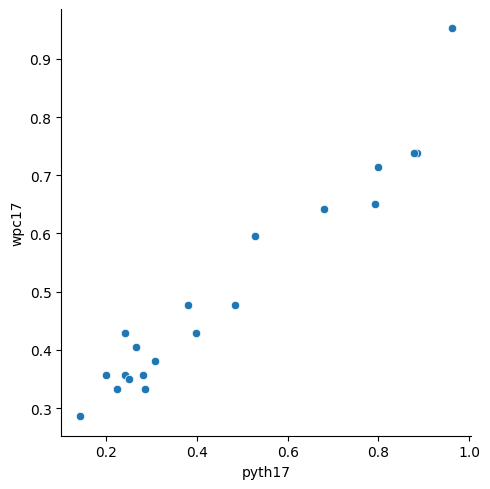

In [ ]:
# Plot the data
sns.relplot(x="pyth17", y="wpc17", data =EPL17)

In [ ]:
# Run the regression
pyth_lm = smf.ols(formula = 'wpc17 ~ pyth17', data=EPL17).fit()
pyth_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  wpc17   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     269.6
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           2.81e-12
Time:                        20:05:14   Log-Likelihood:                 33.822
No. Observations:                  20   AIC:                            -63.64
Df Residuals:                      18   BIC:                            -61.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1978      0.021      9.335      0.000       0.153       0.242
pyth17         0.6551      0.040     16.420      0.000       0.571       0.739
==============================================================================
Omnibus:                        6.775   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.034   Jarque-Bera (JB):                4.322
Skew:                           1.048   Prob(JB):                        0.115
Kurtosis:                       3.891   Cond. No.                         4.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step 9 (=Step 4 (2018))

In [ ]:
# Create a df for 2018 home team performance
EPLhome18 = EPL18.groupby(['HomeTeam'])[['count','hwinvalue', 'FTHG','FTAG']].sum().reset_index()
EPLhome18

,HomeTeam,count,hwinvalue,FTHG,FTAG
0,Arsenal,9,7.5,29,10
1,Bournemouth,8,5.0,12,13
2,Brighton,9,5.5,14,13
3,Burnley,9,3.5,9,11
4,Chelsea,8,4.5,9,9
5,Crystal Palace,8,4.5,15,9
6,Everton,9,5.5,11,9
7,Huddersfield,8,2.5,6,13
8,Leicester,9,5.0,12,8
9,Liverpool,8,7.0,24,6


## Step 9 (=Step 5 (2018))

In [ ]:
# Create a df for 2018 away team performance
EPLaway18 = EPL18.groupby(['AwayTeam'])[['count','awinvalue', 'FTHG','FTAG']].sum().reset_index()
EPLaway18

,AwayTeam,count,awinvalue,FTHG,FTAG
0,Arsenal,8,1.0,15,7
1,Bournemouth,9,4.0,16,13
2,Brighton,8,1.5,16,5
3,Burnley,8,4.0,11,9
4,Chelsea,9,4.5,15,14
5,Crystal Palace,9,4.5,14,12
6,Everton,8,2.5,17,8
7,Huddersfield,9,2.5,13,4
8,Leicester,8,2.5,20,13
9,Liverpool,9,5.0,8,12


## Step 9 (=Step 6 (2018))

In [ ]:
# Rename the variables in both dataframes to specify home or away
EPLhome18 = EPLhome18.rename(columns={'HomeTeam':'team','count':'Ph','FTHG':'FTHGh','FTAG':'FTAGh'})
EPLaway18 = EPLaway18.rename(columns={'AwayTeam':'team','count':'Pa','FTHG':'FTHGa','FTAG':'FTAGa'})

## Step 9 (=Step 7 (2018))

In [ ]:
# Merge the home and away dataframes
EPL18 = pd.merge(EPLhome18, EPLaway18, on = ['team'])
EPL18

,team,Ph,hwinvalue,FTHGh,FTAGh,Pa,awinvalue,FTHGa,FTAGa
0,Arsenal,9,7.5,29,10,8,1.0,15,7
1,Bournemouth,8,5.0,12,13,9,4.0,16,13
2,Brighton,9,5.5,14,13,8,1.5,16,5
3,Burnley,9,3.5,9,11,8,4.0,11,9
4,Chelsea,8,4.5,9,9,9,4.5,15,14
5,Crystal Palace,8,4.5,15,9,9,4.5,14,12
6,Everton,9,5.5,11,9,8,2.5,17,8
7,Huddersfield,8,2.5,6,13,9,2.5,13,4
8,Leicester,9,5.0,12,8,8,2.5,20,13
9,Liverpool,8,7.0,24,6,9,5.0,8,12


## Step 9 (=Step 8 (2018))

In [ ]:
# Sum the results for home and away to get overall performance and calculate win percentage and pythagorean expectation
EPL18['W18'] = EPL18['hwinvalue']+EPL18['awinvalue']
EPL18['G18'] = EPL18['Ph']+EPL18['Pa']
EPL18['GF18'] = EPL18['FTHGh']+EPL18['FTAGa']
EPL18['GA18'] = EPL18['FTAGh']+EPL18['FTHGa']
EPL18['wpc18'] = EPL18['W18']/EPL18['G18']
EPL18['pyth18'] = EPL18['GF18']**2/(EPL18['GF18']**2 + EPL18['GA18']**2)
EPL18

,team,Ph,hwinvalue,FTHGh,FTAGh,Pa,awinvalue,FTHGa,FTAGa,W18,G18,GF18,GA18,wpc18,pyth18
0,Arsenal,9,7.5,29,10,8,1.0,15,7,8.5,17,36,25,0.500000,0.674649
1,Bournemouth,8,5.0,12,13,9,4.0,16,13,9.0,17,25,29,0.529412,0.426330
2,Brighton,9,5.5,14,13,8,1.5,16,5,7.0,17,19,29,0.411765,0.300333
3,Burnley,9,3.5,9,11,8,4.0,11,9,7.5,17,18,22,0.441176,0.400990
4,Chelsea,8,4.5,9,9,9,4.5,15,14,9.0,17,23,24,0.529412,0.478733
5,Crystal Palace,8,4.5,15,9,9,4.5,14,12,9.0,17,27,23,0.529412,0.579491
6,Everton,9,5.5,11,9,8,2.5,17,8,8.0,17,19,26,0.470588,0.348120
7,Huddersfield,8,2.5,6,13,9,2.5,13,4,5.0,17,10,26,0.294118,0.128866
8,Leicester,9,5.0,12,8,8,2.5,20,13,7.5,17,25,28,0.441176,0.443577
9,Liverpool,8,7.0,24,6,9,5.0,8,12,12.0,17,36,14,0.705882,0.868633


## Optional steps, not required for Assessment
### (Uncomment to run)

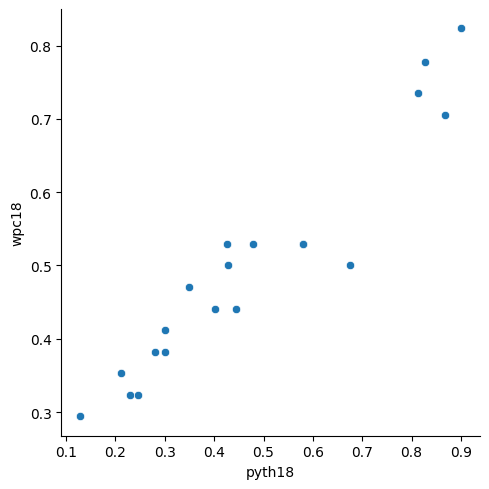

In [ ]:
# Plot the data
sns.relplot(x="pyth18", y="wpc18", data =EPL18)

In [ ]:
# Run the regression
pyth_lm = smf.ols(formula = 'wpc18 ~ pyth18', data=EPL18).fit()
pyth_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  wpc18   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     191.1
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           5.02e-11
Time:                        20:07:49   Log-Likelihood:                 34.030
No. Observations:                  20   AIC:                            -64.06
Df Residuals:                      18   BIC:                            -62.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2040      0.024      8.586      0.000       0.154       0.254
pyth18         0.6237      0.045     13.823      0.000       0.529       0.718
==============================================================================
Omnibus:                        5.199   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.074   Jarque-Bera (JB):                2.933
Skew:                          -0.826   Prob(JB):                        0.231
Kurtosis:                       3.890   Cond. No.                         5.35
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Step 10

In [ ]:
# Merge 2017 and 2018 dataframes
EPL17_18 = pd.merge(EPL17,EPL18, on='team')
EPL17_18

,team,Ph_x,hwinvalue_x,FTHGh_x,FTAGh_x,Pa_x,awinvalue_x,FTHGa_x,FTAGa_x,W17,...,Pa_y,awinvalue_y,FTHGa_y,FTAGa_y,W18,G18,GF18,GA18,wpc18,pyth18
0,Arsenal,10,8.5,25,10,11,5.0,16,13,13.5,...,8,1.0,15,7,8.5,17,36,25,0.500000,0.674649
1,Bournemouth,11,4.5,14,17,10,3.0,15,6,7.5,...,9,4.0,16,13,9.0,17,25,29,0.529412,0.426330
2,Brighton,10,5.5,10,12,11,3.0,13,5,8.5,...,8,1.5,16,5,7.0,17,19,29,0.411765,0.300333
3,Burnley,10,6.0,7,6,11,6.5,11,11,12.5,...,8,4.0,11,9,7.5,17,18,22,0.441176,0.400990
4,Chelsea,11,8.5,21,7,10,7.0,7,18,15.5,...,9,4.5,15,14,9.0,17,23,24,0.529412,0.478733
5,Crystal Palace,11,5.0,14,18,10,2.5,14,4,7.5,...,9,4.5,14,12,9.0,17,27,23,0.529412,0.579491
6,Everton,10,6.5,17,13,11,3.5,19,8,10.0,...,8,2.5,17,8,8.0,17,19,26,0.470588,0.348120
7,Huddersfield,11,6.0,10,12,10,3.0,20,8,9.0,...,9,2.5,13,4,5.0,17,10,26,0.294118,0.128866
8,Leicester,10,5.0,13,14,11,5.0,18,18,10.0,...,8,2.5,20,13,7.5,17,25,28,0.441176,0.443577
9,Liverpool,11,8.5,21,4,10,6.5,20,27,15.0,...,9,5.0,8,12,12.0,17,36,14,0.705882,0.868633


## Step 11

In [ ]:
# Generate a correlation matrix for wpc and pyth for 2017 and 2018
keyvars = EPL17_18[['wpc17','wpc18','pyth17','pyth18']]
keyvars.corr()

,wpc17,wpc18,pyth17,pyth18
wpc17,1.000000,0.756573,0.968204,0.745832
wpc18,0.756573,1.000000,0.795693,0.955986
pyth17,0.968204,0.795693,1.000000,0.795331
pyth18,0.745832,0.955986,0.795331,1.000000


## Optional steps, not required for Assessment
### (Uncomment to run)

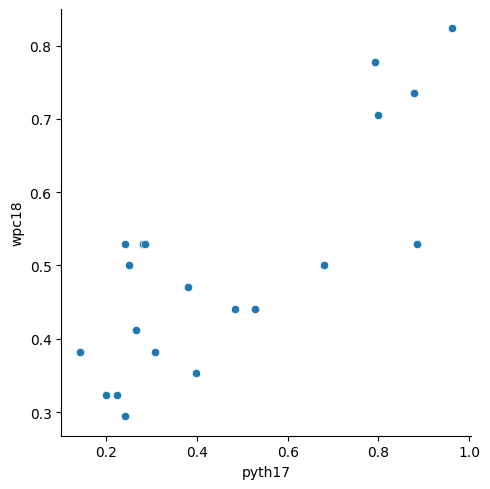

In [ ]:
sns.relplot(x="pyth17", y="wpc18", data =EPL17_18)

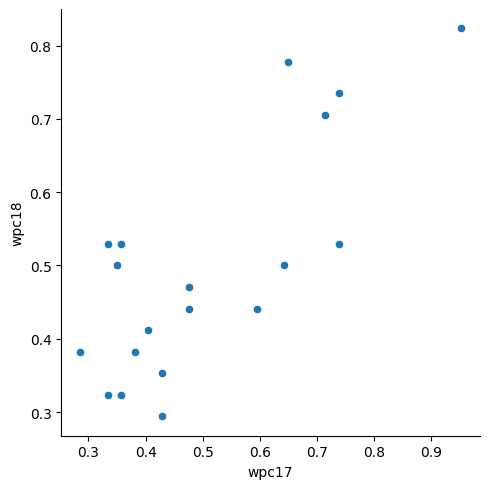

In [ ]:
sns.relplot(x="wpc17", y="wpc18", data =EPL17_18)

Now you have completed the assignment, are these results consistent with those we found for Major League Baseball?

The results are very similar to that of the Major League Baseball case study.  There is a statistically significant relationship and the pythagorean expectation in the first half of the season is the best predictor for the winning percentage in the second half of the season.